## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_max=10,
# k_bar=10, plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="dyca",
    scaling_mode="scaler",

    # DyCA-Stufe: m lineare Komponenten, n Dimension des
    # deterministischen Systems. Randbedingungen des Pakets:
    # n >= m und m >= n - m. Die Schaetzzelle unten hilft
    # bei der Wahl.
    dyca_m=2,
    dyca_n=4,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...
  fertig.


## m und n schätzen

DyCA braucht zwei Vorgaben: *m* lineare Komponenten und *n* als Dimension des deterministischen Systems. Beide sollten aus den Normalbetriebsdaten abgelesen werden, nicht geraten. Die zwei Diagnoseplots darunter zeigen, was die Daten nahelegen.

Referenz-Run shape: (500, 52)


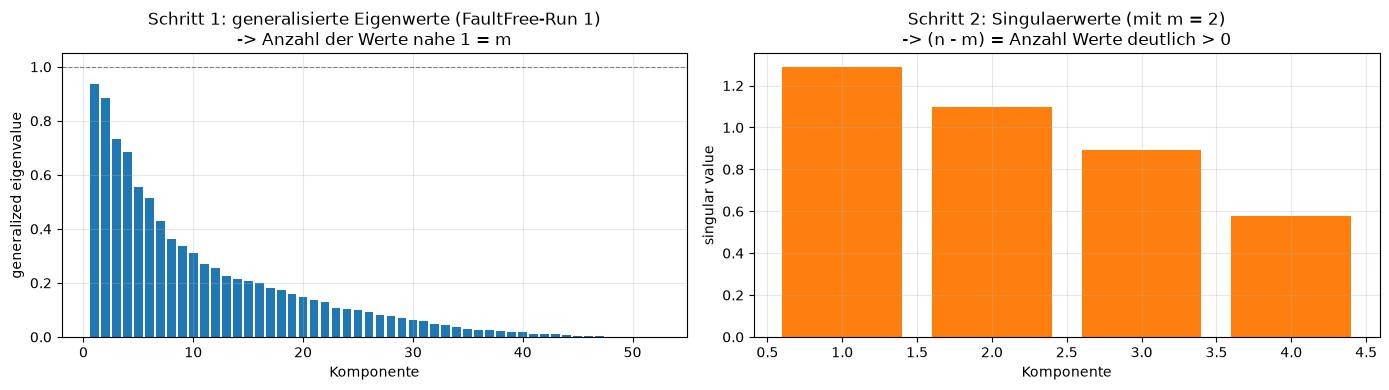


Aktuelle Einstellung: dyca_m = 2, dyca_n = 4
Legen die Plots eine andere Wahl nahe, in der Konfigurations-zelle aendern und neu ausfuehren.


In [4]:
# ============================================================
# m und n aus den FaultFree-Daten schaetzen
# ============================================================
# Links: generalisierte Eigenwerte ohne m-Vorgabe - die Anzahl der Werte
# nahe 1 ist das gesuchte m. Rechts: Singulaerwerte bei vorgegebenem m -
# die Anzahl der deutlich von null verschiedenen Werte ist (n - m).
# Der Referenzlauf wird mit DEMSELBEN scaling_mode vorverarbeitet wie die
# Produktivschleife, Schaetzung und Lauf koennen also nicht auseinander-
# driften.
from tep.eigen import plot_dyca_mn_estimate

_ = plot_dyca_mn_estimate(CFG, df_ff, scaler)

## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [5]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne DyCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10443
Uebersprungen   : 0 (weniger als 9 Samples)
Fehler          : 57
Erste Fehler:
  fault=0, run=170: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=15: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=93: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=227: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=338: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.


,faultNumber,simulationRun,dyca_1,dyca_2,dyca_3,dyca_4,dyca_5,dyca_6,dyca_7,dyca_8,...,dyca_43,dyca_44,dyca_45,dyca_46,dyca_47,dyca_48,dyca_49,dyca_50,dyca_51,dyca_52
0,0,1,0.937925,0.884058,0.731876,0.683042,0.553713,0.515547,0.429585,0.363507,...,0.009682,0.006073,0.004243,0.002865,0.002230,0.001380,0.000989,0.000064,0.000031,4.945879e-08
1,0,2,0.951325,0.929498,0.804556,0.754866,0.534190,0.498709,0.437902,0.402709,...,0.006848,0.005209,0.004251,0.003157,0.002878,0.002342,0.001088,0.000922,0.000401,2.223355e-04
2,0,3,0.930672,0.906695,0.736079,0.715722,0.534306,0.493845,0.413278,0.395503,...,0.007774,0.007267,0.005547,0.004385,0.002838,0.001408,0.001227,0.001175,0.000011,6.086561e-09
3,0,4,0.934602,0.907673,0.771981,0.676296,0.574108,0.502733,0.429072,0.401868,...,0.011595,0.008988,0.005812,0.004855,0.003128,0.001962,0.001384,0.000647,0.000087,4.001539e-05
4,0,5,0.938671,0.878161,0.770026,0.625239,0.530168,0.481434,0.467164,0.413289,...,0.008330,0.007109,0.006130,0.004349,0.004160,0.002866,0.002158,0.000654,0.000064,3.624826e-05


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [6]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte DyCA-Statistiken pro Fault: (21, 105)


,faultNumber,dyca_1_mean,dyca_1_std,dyca_2_mean,dyca_2_std,dyca_3_mean,dyca_3_std,dyca_4_mean,dyca_4_std,dyca_5_mean,...,dyca_48_mean,dyca_48_std,dyca_49_mean,dyca_49_std,dyca_50_mean,dyca_50_std,dyca_51_mean,dyca_51_std,dyca_52_mean,dyca_52_std
0,0,0.931788,0.008202,0.889915,0.018190,0.760545,0.028084,0.667612,0.036494,0.534702,...,0.001776,0.000613,0.000882,0.000415,0.000522,0.000331,0.000117,0.000119,0.000030,0.000052
1,1,0.984565,0.002572,0.956127,0.004943,0.926065,0.008160,0.780618,0.018415,0.693309,...,0.001542,0.000632,0.000836,0.000410,0.000381,0.000244,0.000114,0.000107,0.000016,0.000027
2,2,0.943312,0.005631,0.910242,0.011518,0.808294,0.022283,0.700710,0.024380,0.551253,...,0.001490,0.000544,0.000849,0.000380,0.000391,0.000239,0.000116,0.000107,0.000014,0.000025
3,3,0.932797,0.008309,0.892401,0.018285,0.764173,0.027969,0.672603,0.035855,0.537449,...,0.001818,0.000682,0.000962,0.000446,0.000536,0.000323,0.000130,0.000127,0.000028,0.000051
4,4,0.932709,0.008255,0.893406,0.017957,0.770326,0.027674,0.676834,0.033499,0.578238,...,0.001507,0.000566,0.000834,0.000381,0.000360,0.000225,0.000110,0.000102,0.000012,0.000022


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

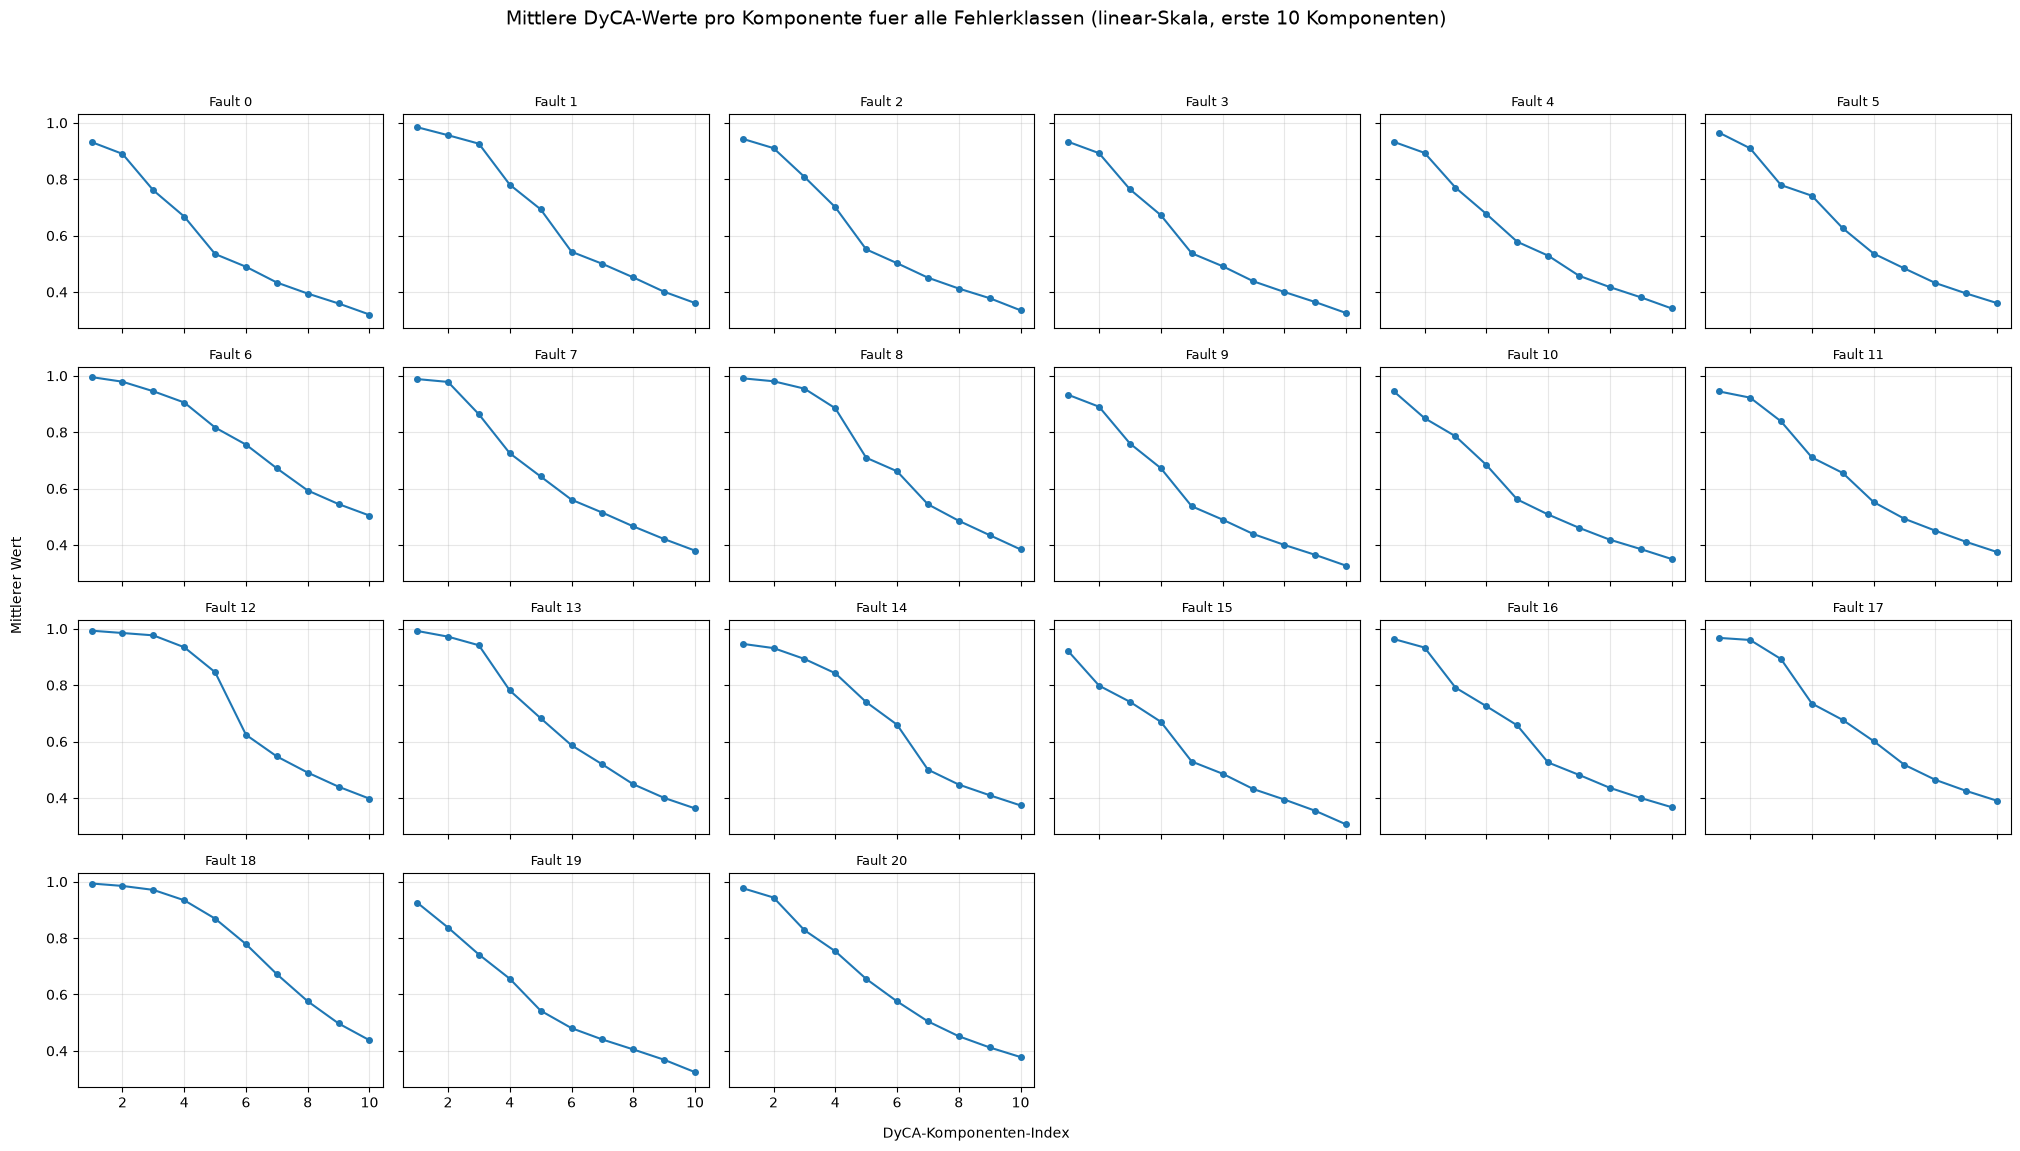

In [7]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

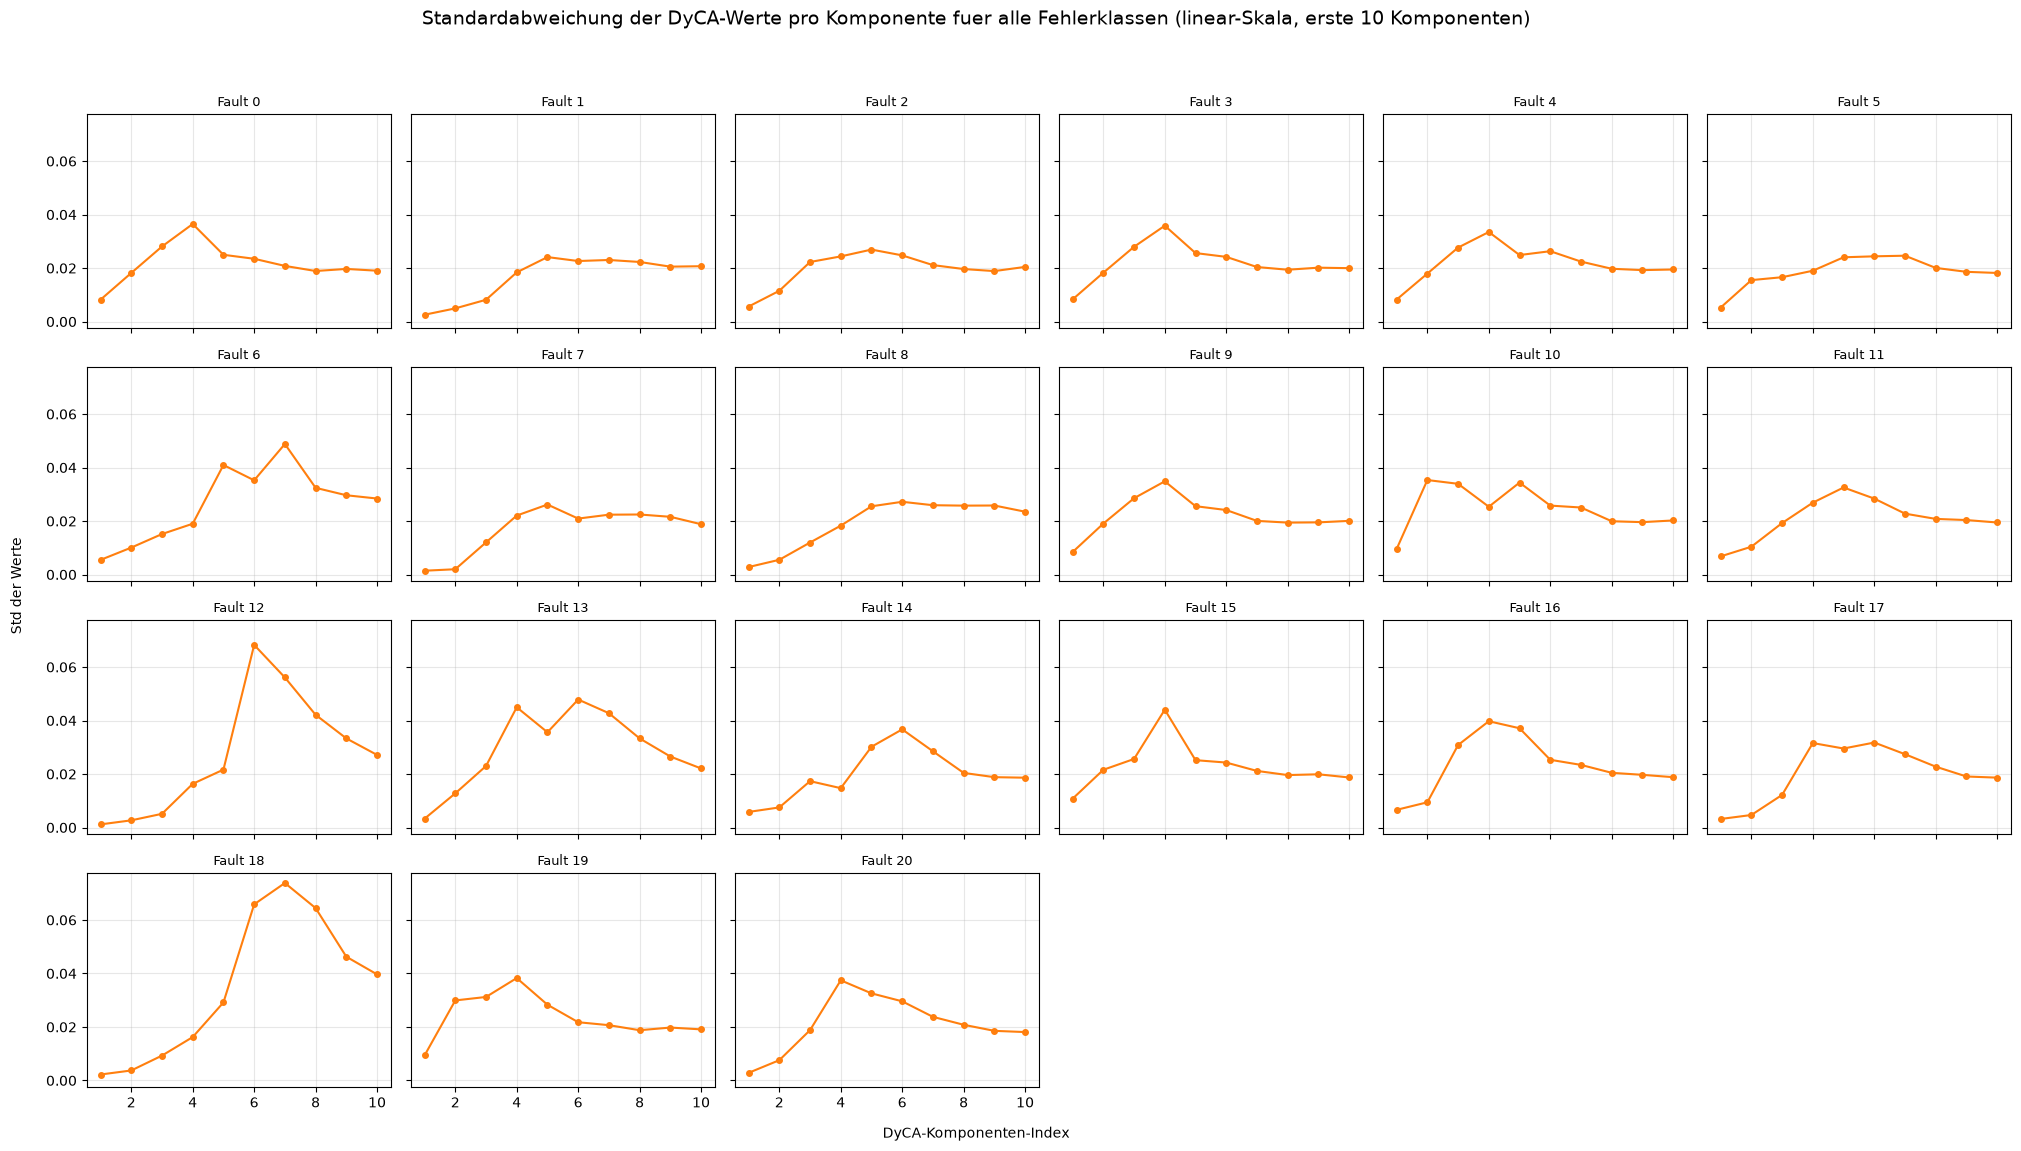

In [8]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

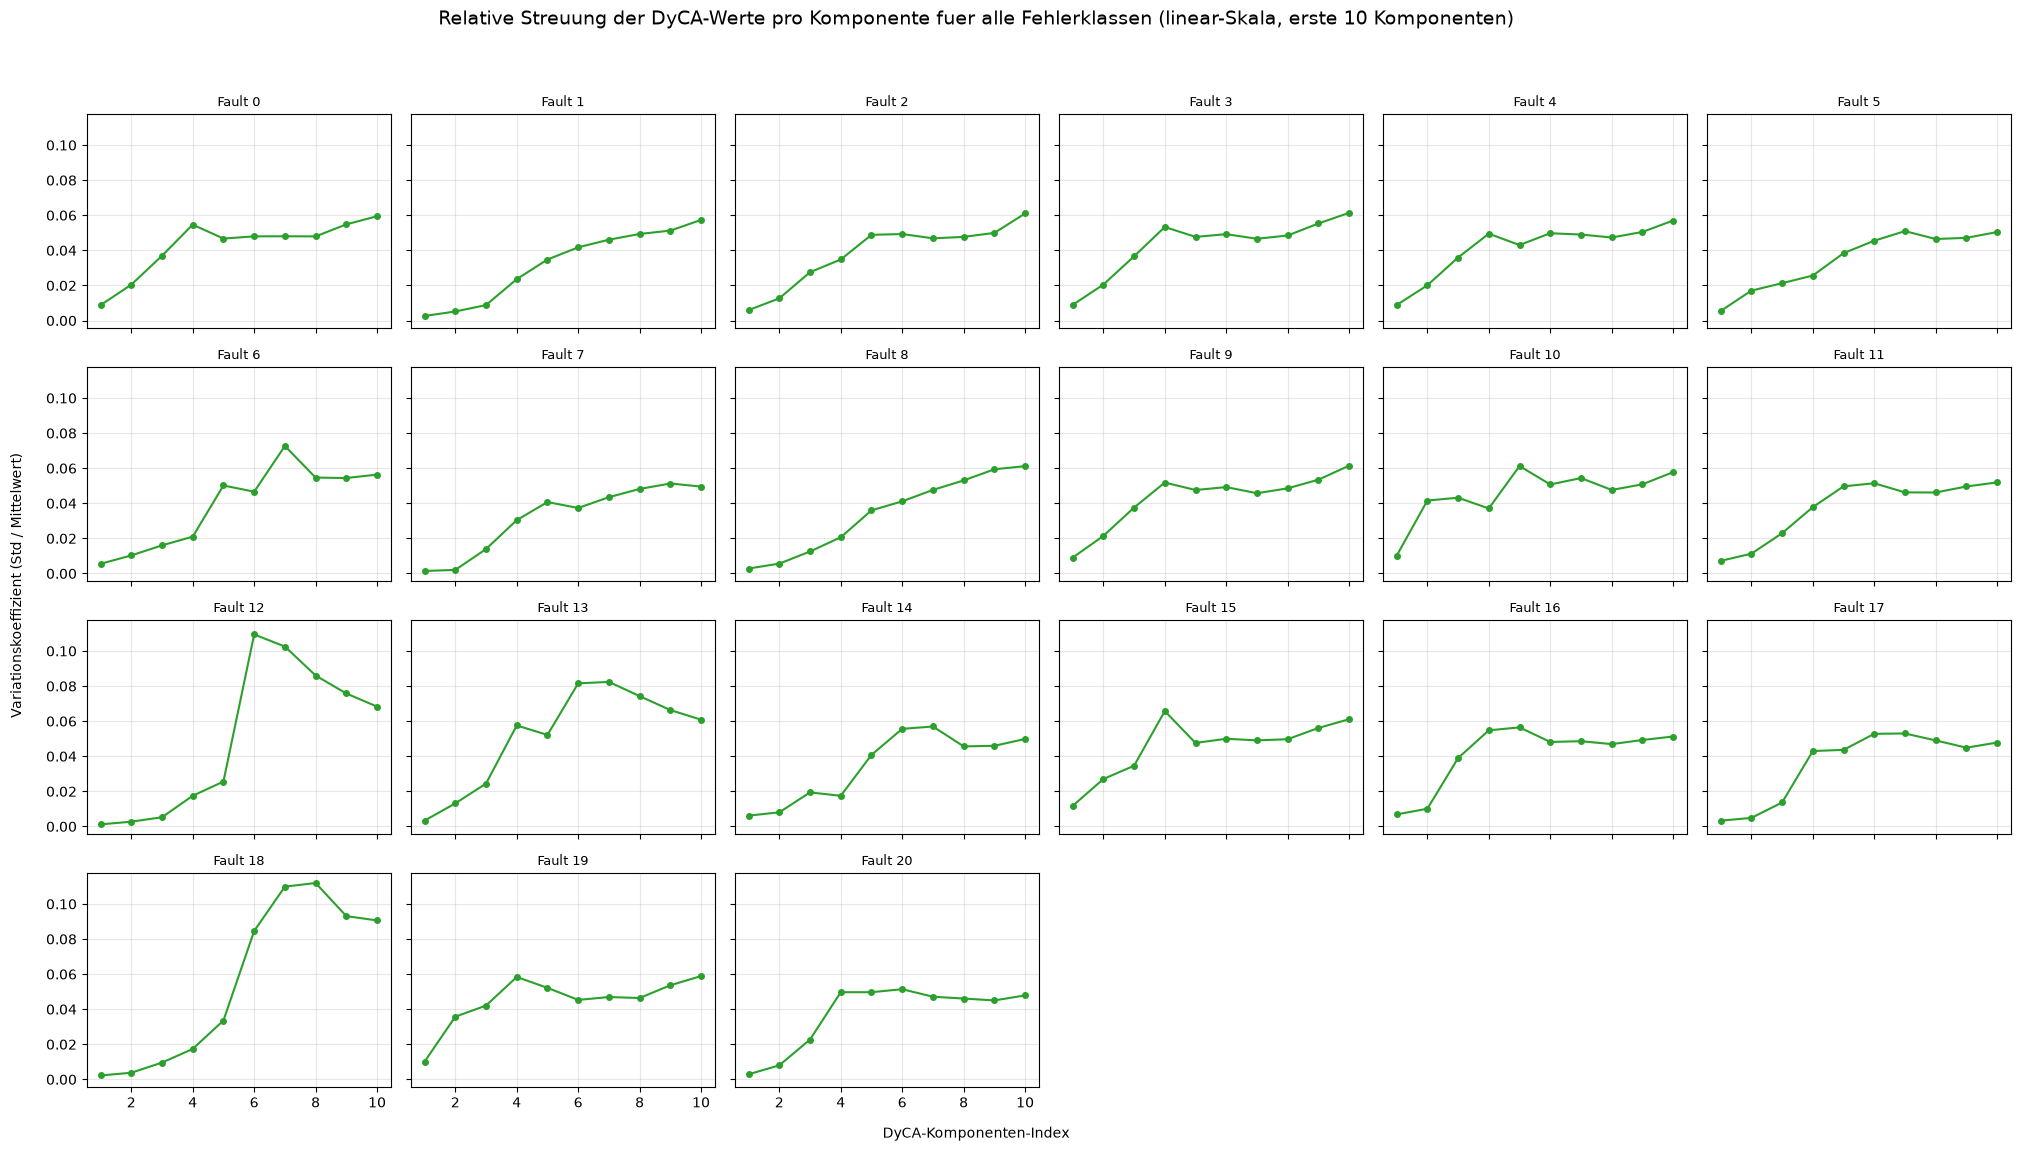

In [9]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

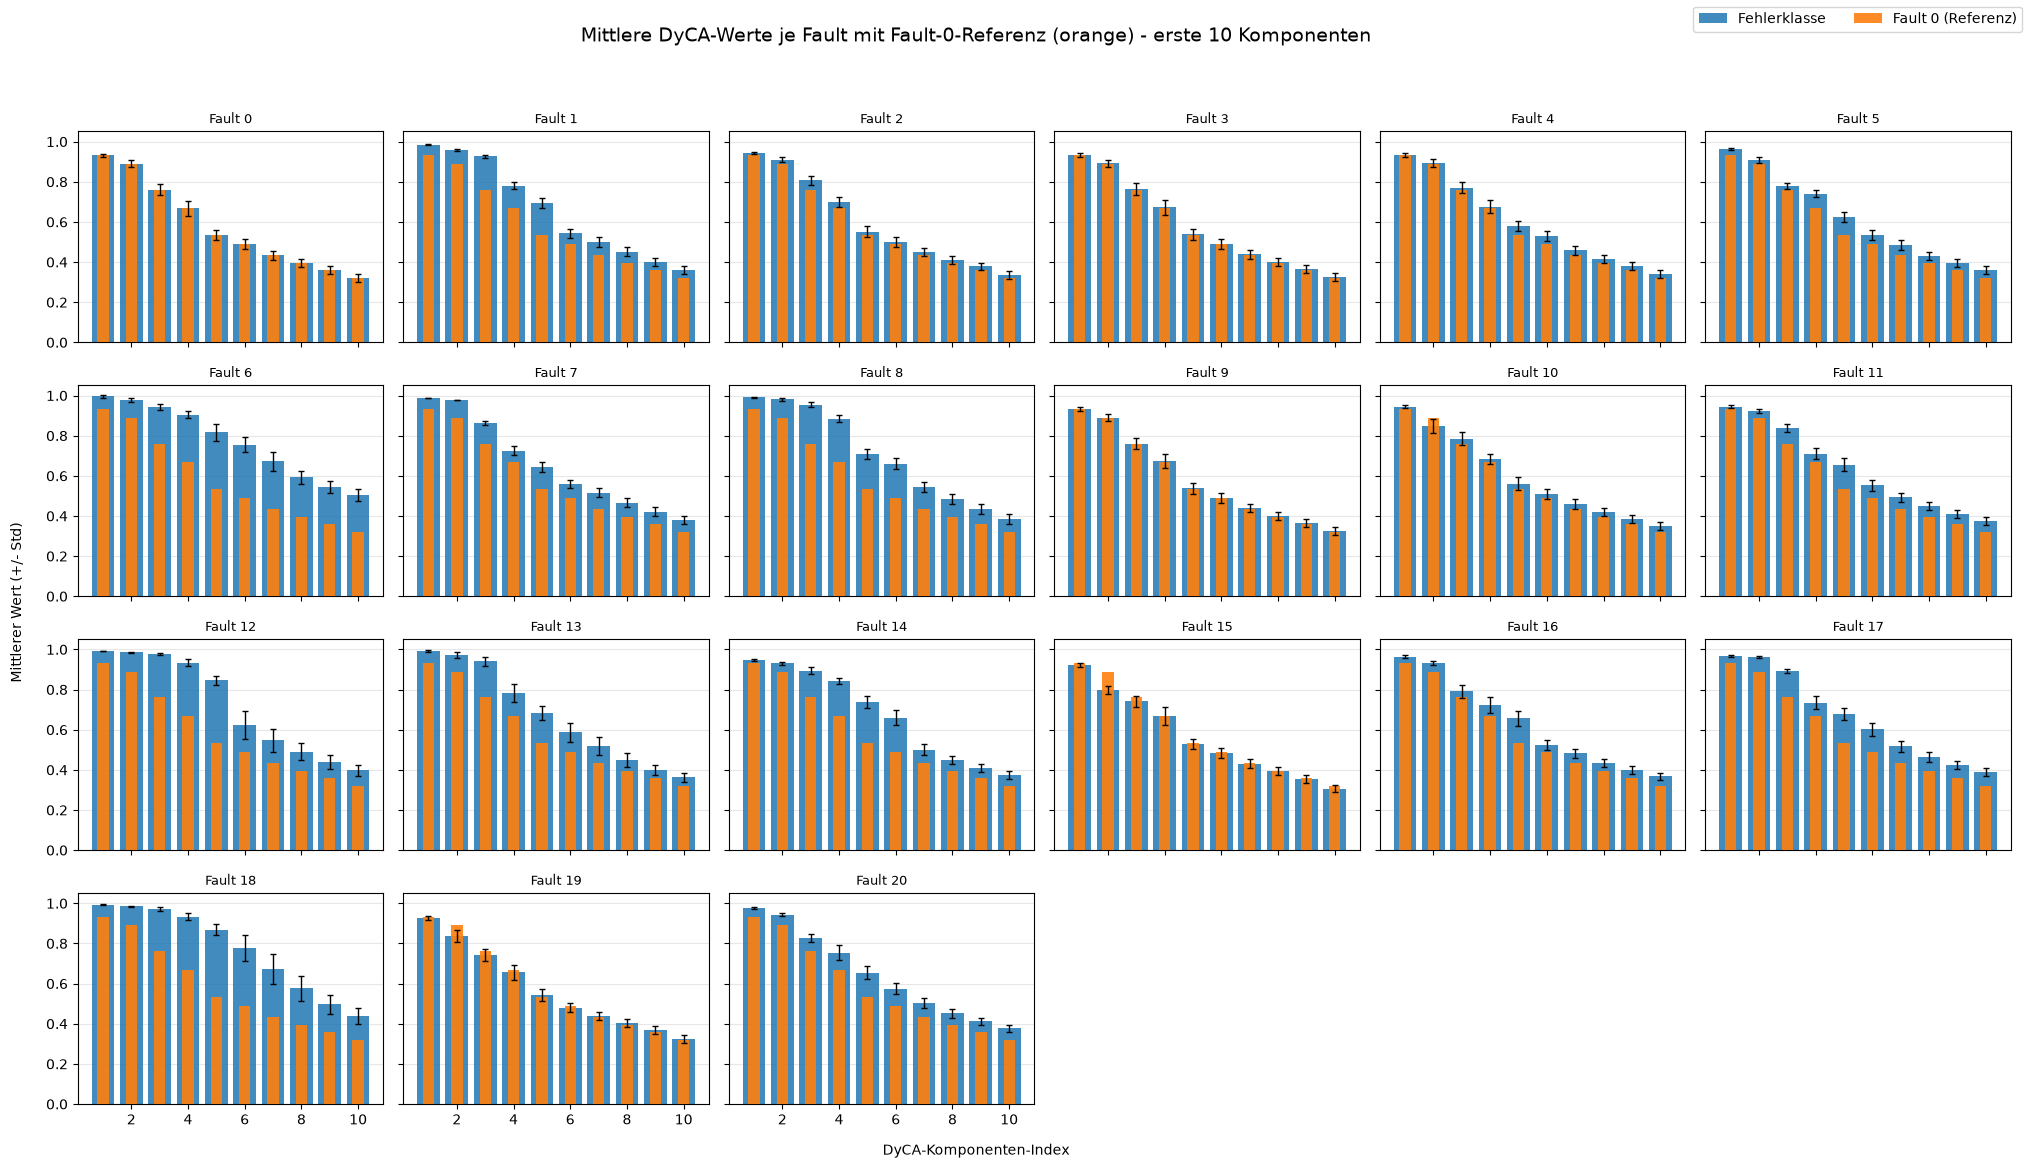

In [10]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `dyca_eigenvalues_train_scaler.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [11]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

DyCA-Train gespeichert: (10443, 54) -> .\dyca_eigenvalues_train_scaler.csv


'.\\dyca_eigenvalues_train_scaler.csv'